### Generate spherical ROIs based on meta-analysis peak coordinates

###### NC 06-05-2025

In [2]:
from nilearn import plotting, masking
from nilearn.masking import _unmask_3d
from nilearn.maskers import nifti_spheres_masker
import nibabel as nib
from nibabel import Nifti1Image


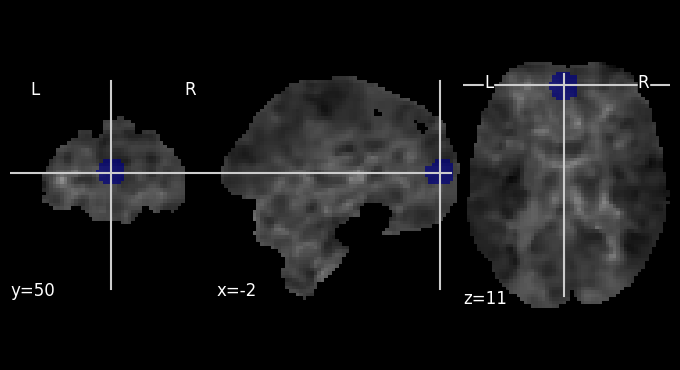

In [15]:
### ACC ROI from Lin 
coords = (-2, 50, 12)

space_defining_image = masking.compute_brain_mask("/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")

_, A = nifti_spheres_masker._apply_mask_and_get_affinity(
    seeds=[coords],
    niimg=None,
    radius=10,
    allow_overlap=False, 
    mask_img=space_defining_image)

sphere_mask = _unmask_3d(
    X=A.toarray().flatten(), 
    mask=space_defining_image.get_fdata().astype(bool))

sphere_mask = Nifti1Image(sphere_mask, space_defining_image.affine)

nib.save(sphere_mask, "ACC_10mm.nii.gz")

plotting.plot_roi("ACC_10mm.nii.gz", bg_img="/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")
plotting.show()

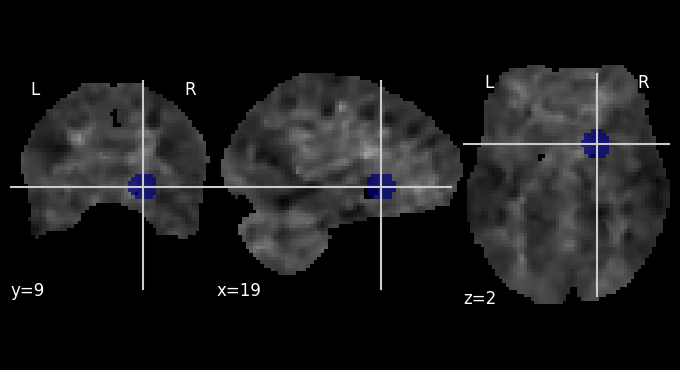

In [22]:
## Striatum ROI from Lin 

coords = (20, 10, 2)

space_defining_image = masking.compute_brain_mask("/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")

_, A = nifti_spheres_masker._apply_mask_and_get_affinity(
    seeds=[coords],
    niimg=None,
    radius=10,
    allow_overlap=False, 
    mask_img=space_defining_image)

sphere_mask = _unmask_3d(
    X=A.toarray().flatten(), 
    mask=space_defining_image.get_fdata().astype(bool))

sphere_mask = Nifti1Image(sphere_mask, space_defining_image.affine)

nib.save(sphere_mask, "Striatum_R_10mm.nii.gz")

plotting.plot_roi("Striatum_R_10mm.nii.gz", bg_img="/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")
plotting.show()

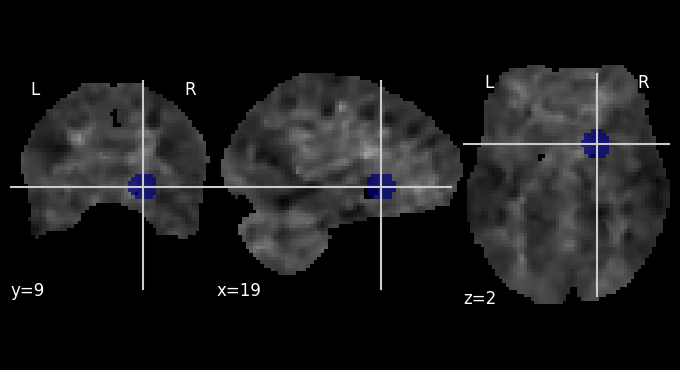

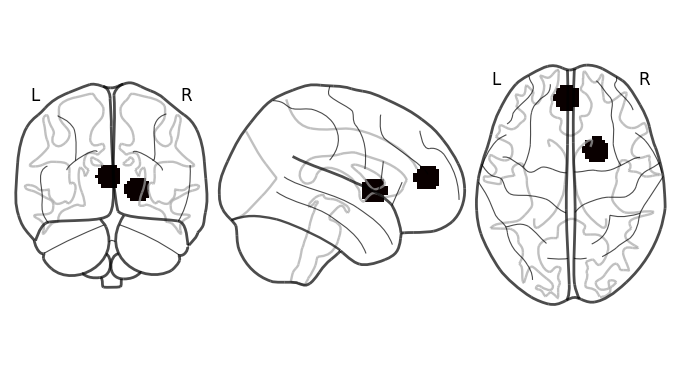

In [25]:
# Create the union mask
import nilearn 

#nilearn.masking.intersect_masks(mask_imgs, threshold=0.5, connected=True)
unionmask = nilearn.masking.intersect_masks(["Striatum_R_10mm.nii.gz","ACC_10mm.nii.gz"],threshold=0,connected=False)
nib.save(unionmask, "LinUnion_10.nii.gz")

plotting.plot_roi("LinUnion_10.nii.gz", bg_img="/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")
plotting.show()


nilearn.plotting.plot_glass_brain("LinUnion_10.nii.gz", output_file=None, display_mode='ortho', colorbar=False, cbar_tick_format='%.2g', figure=None, axes=None, title=None, threshold='auto', annotate=True, black_bg=False, cmap=None, alpha=0.7, vmin=None, vmax=None, plot_abs=True, symmetric_cbar='auto', resampling_interpolation='continuous', radiological=False)

In [3]:
### ACC ROI from Lin 

#coordslist = [[-1,41,0],[-50,41,0]]
coordslist =[[-6,-53,24],	[-1,41,0],	[37,-72,-9],	[-15,43,35],	[-12,-83,31],	[-41,-66,-16],	[-44,-70,13],	[43,-32,4],	[9,-77,-19],	[-5,23,23],	[9,-22,24],	[3,34,18],	[-52,-50,24],	[16,-68,43],	[0,-37,59],	[-10,-69,-15],	[-25,-1,63],	[53,-63,20],	[-12,-35,-29],	[34,-21,57],	[16,47,20],	[-46,-62,28],	[-30,-1,-7],	[-27,-27,14],	[-15,-60,61],	[-39,-4,-23],	[15,-82,31],	[-29,-79,29],	[39,-49,-23],	[5,-45,-19],	[29,-5,1],	[6,-76,25],	[28,-28,45],	[16,-10,-5],	[9,20,31],	[-48,-40,7],	[0,-16,34],	[18,-37,40],	[12,-52,61],	[-18,-22,-14],	[24,-82,10],	[-30,-34,52],	[0,-10,64],	[12,-91,7]]
index=0

for coordinate in coordslist:
    index=index+1
    coords=coordinate
    
    space_defining_image = masking.compute_brain_mask("/data00/projects/geoscan_v2/data/bids_data/derivatives_nocorrection/nipype/task-image_model-GEO-condition/l2analysis/standardSmoke_v_standardNonsmoke/spmT_0001.nii")
    
    _, A = nifti_spheres_masker._apply_mask_and_get_affinity(
        seeds=[coords],
        niimg=None,
        radius=10,
        allow_overlap=False, 
        mask_img=space_defining_image)
    
    sphere_mask = _unmask_3d(
        X=A.toarray().flatten(), 
        mask=space_defining_image.get_fdata().astype(bool))
    
    sphere_mask = Nifti1Image(sphere_mask, space_defining_image.affine)
    
    nib.save(sphere_mask, ("Engelmann" + str(index) + ".nii.gz"))

In [4]:
index

44

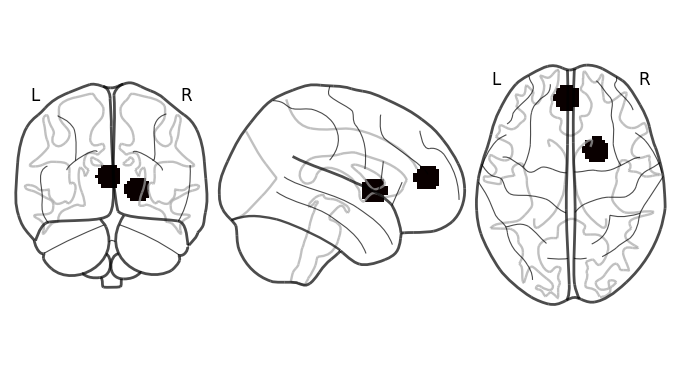

In [5]:
# Create the union mask
import nilearn 

#nilearn.masking.intersect_masks(mask_imgs, threshold=0.5, connected=True)
unionmask = nilearn.masking.intersect_masks(["Engelmann1.nii.gz","Engelmann2.nii.gz","Engelmann3.nii.gz","Engelmann4.nii.gz","Engelmann5.nii.gz","Engelmann6.nii.gz","Engelmann7.nii.gz","Engelmann8.nii.gz","Engelmann9.nii.gz","Engelmann10.nii.gz","Engelmann11.nii.gz","Engelmann12.nii.gz","Engelmann13.nii.gz","Engelmann14.nii.gz","Engelmann15.nii.gz","Engelmann16.nii.gz","Engelmann17.nii.gz","Engelmann18.nii.gz","Engelmann19.nii.gz","Engelmann20.nii.gz","Engelmann21.nii.gz","Engelmann22.nii.gz","Engelmann23.nii.gz","Engelmann24.nii.gz","Engelmann25.nii.gz","Engelmann26.nii.gz","Engelmann27.nii.gz","Engelmann28.nii.gz","Engelmann29.nii.gz","Engelmann30.nii.gz","Engelmann31.nii.gz","Engelmann32.nii.gz","Engelmann33.nii.gz","Engelmann34.nii.gz","Engelmann35.nii.gz","Engelmann36.nii.gz","Engelmann37.nii.gz","Engelmann38.nii.gz","Engelmann39.nii.gz","Engelmann40.nii.gz","Engelmann41.nii.gz","Engelmann42.nii.gz","Engelmann43.nii.gz","Engelmann44.nii.gz",],threshold=0,connected=False)
nib.save(unionmask, "EngelmannUnion_10.nii.gz")



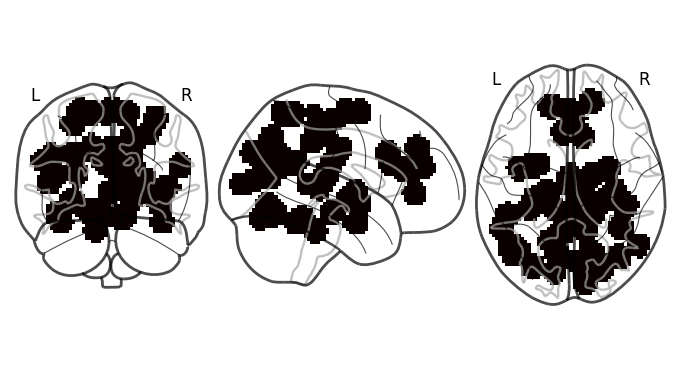

In [6]:
nilearn.plotting.plot_glass_brain("EngelmannUnion_10.nii.gz", output_file=None, display_mode='ortho', colorbar=False, cbar_tick_format='%.2g', figure=None, axes=None, title=None, threshold='auto', annotate=True, black_bg=False, cmap=None, alpha=0.7, vmin=None, vmax=None, plot_abs=True, symmetric_cbar='auto', resampling_interpolation='continuous', radiological=False)